# Level 2 (Intermediate) Machine Learning Tasks
This notebook covers:
- **Task 1:** Predictive Modeling (Regression)
- **Task 2:** Classification with Logistic Regression
- **Task 3:** Clustering (Unsupervised Learning)

In [ ]:
# Install dependencies if needed
# !pip install scikit-learn pandas matplotlib seaborn

---
# Task 1: Predictive Modeling (Regression)
**Goal:** Predict house prices using the California Housing dataset.

**Dataset:** `sklearn.datasets.fetch_california_housing` — 20,640 samples, 8 features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print('Shape:', df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


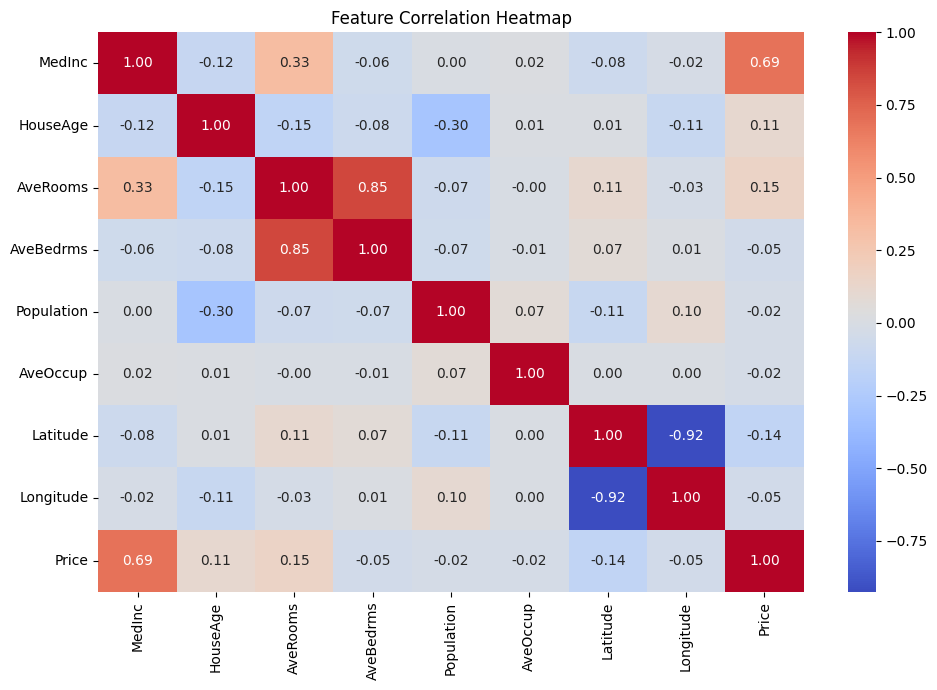

In [3]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [4]:
# Train/test split
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (16512, 8), Test size: (4128, 8)


In [5]:
# Train and evaluate multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': round(mse, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)}
    print(f'{name}: MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}')

results_df = pd.DataFrame(results).T
results_df

Linear Regression: MSE=0.5559, RMSE=0.7456, R²=0.5758
Decision Tree: MSE=0.5245, RMSE=0.7242, R²=0.5997
Random Forest: MSE=0.2552, RMSE=0.5051, R²=0.8053


,MSE,RMSE,R²
Linear Regression,0.5559,0.7456,0.5758
Decision Tree,0.5245,0.7242,0.5997
Random Forest,0.2552,0.5051,0.8053


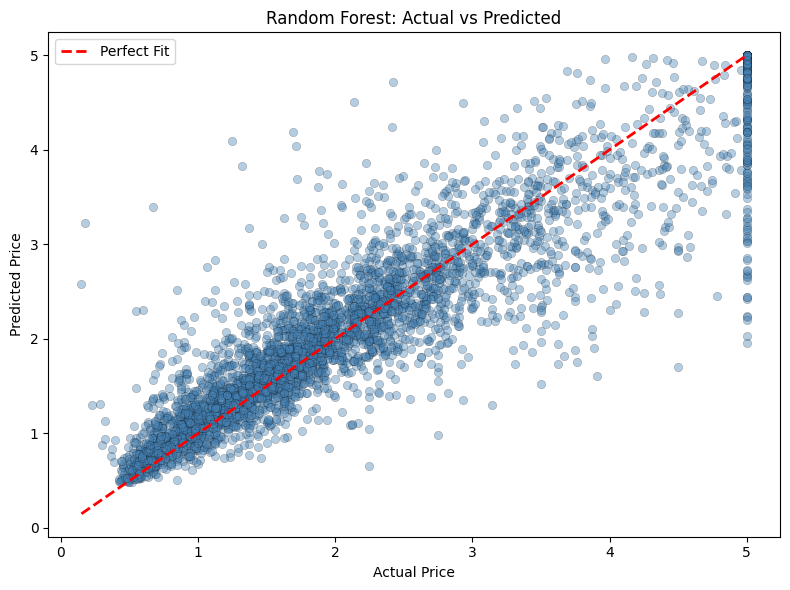

In [6]:
# Plot: Actual vs Predicted (Best model - Random Forest)
rf = models['Random Forest']
y_pred_rf = rf.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

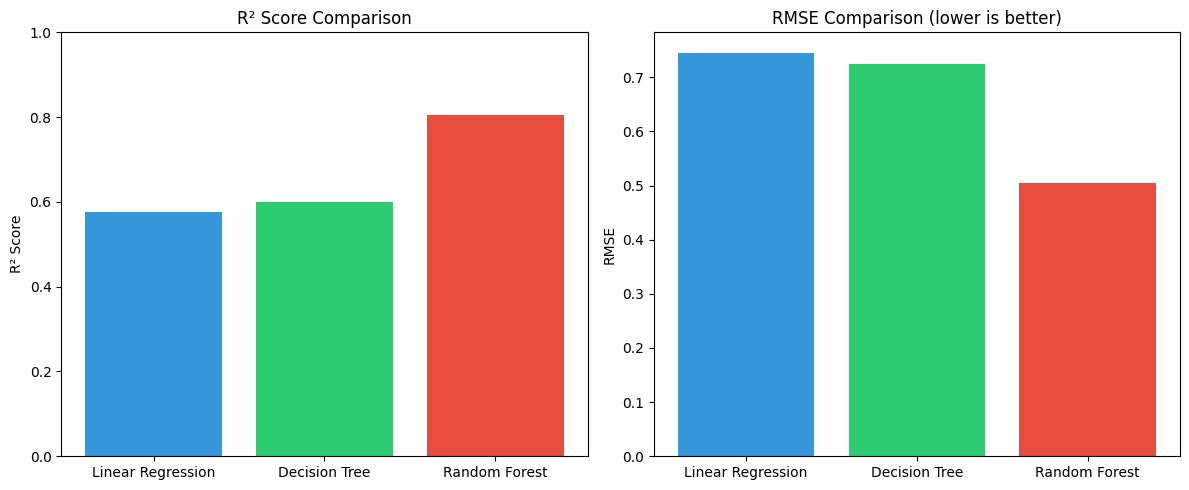


✅ Task 1 Summary:
Best model: Random Forest (R²=0.8053)


In [7]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = list(results.keys())
r2_scores = [results[m]['R²'] for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]

axes[0].bar(model_names, r2_scores, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)

axes[1].bar(model_names, rmse_scores, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('RMSE Comparison (lower is better)')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

print('\n✅ Task 1 Summary:')
print(f'Best model: Random Forest (R²={results["Random Forest"]["R²"]})')

---
# Task 2: Classification with Logistic Regression
**Goal:** Classify flower species using the Iris dataset.

**Dataset:** `sklearn.datasets.load_iris` — 150 samples, 4 features, 3 classes.

In [8]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Load dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['Species'] = iris.target
df_iris['SpeciesName'] = [iris.target_names[i] for i in iris.target]

print('Shape:', df_iris.shape)
print('Classes:', iris.target_names)
df_iris.head()

Shape: (150, 6)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,SpeciesName
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


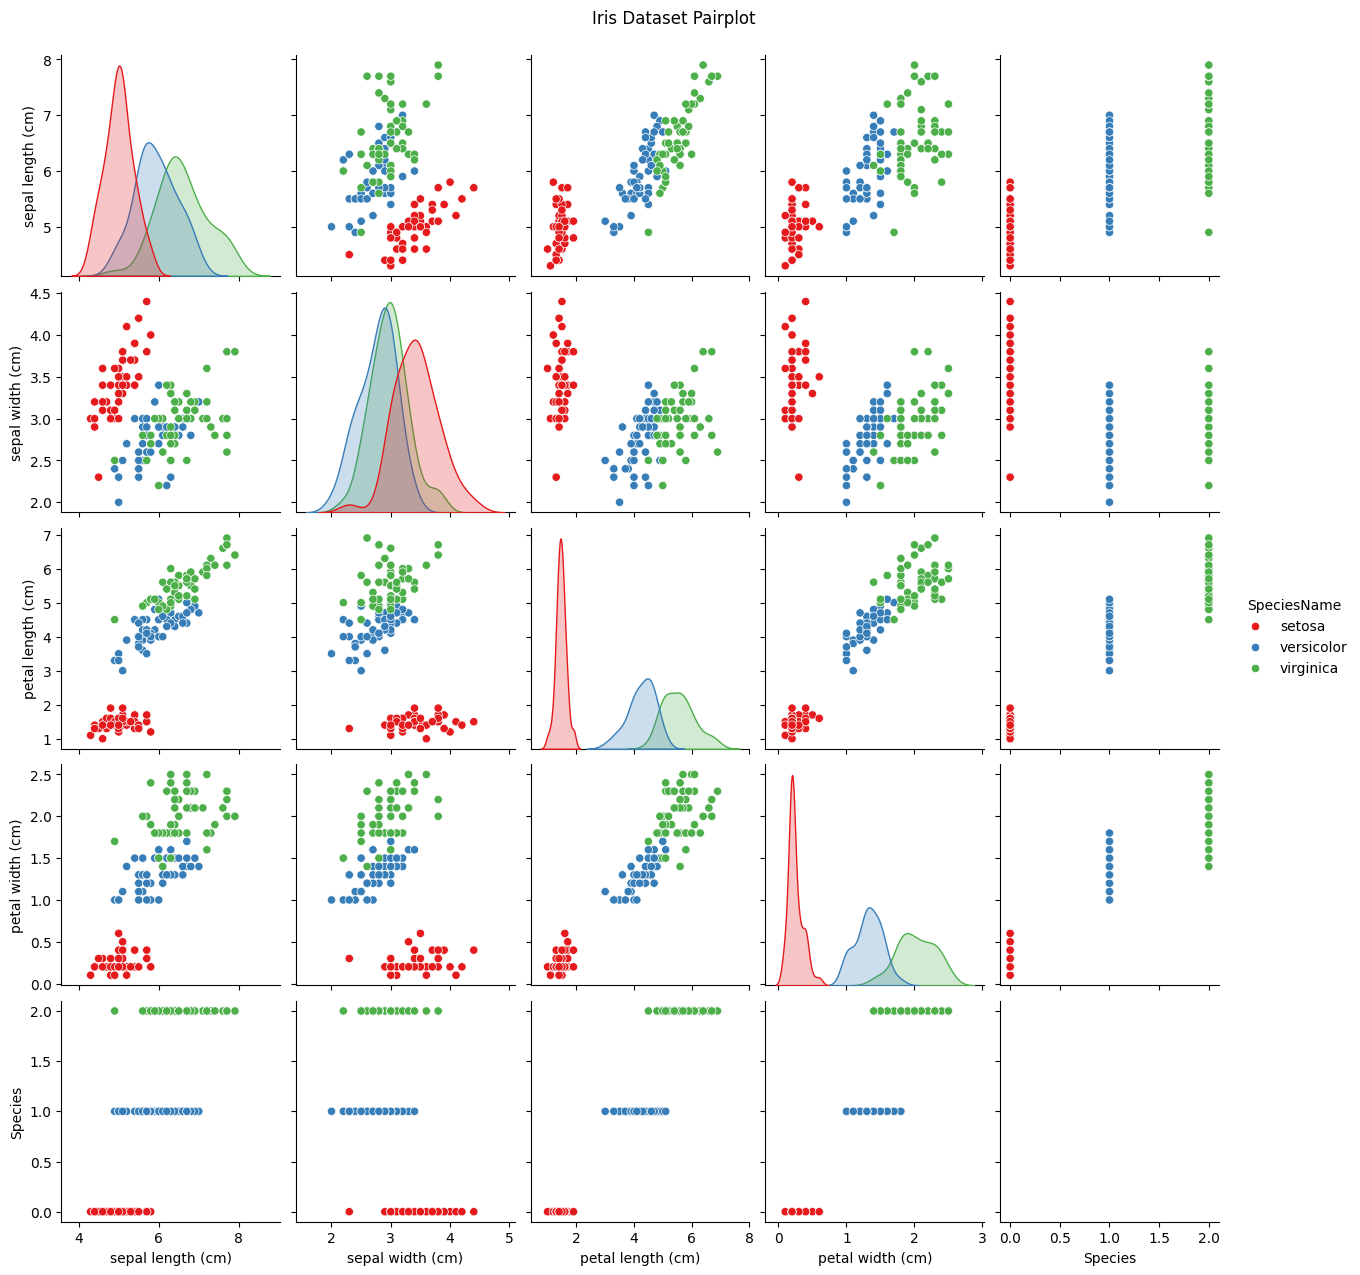

In [9]:
# Pairplot to visualize features
sns.pairplot(df_iris, hue='SpeciesName', palette='Set1')
plt.suptitle('Iris Dataset Pairplot', y=1.02)
plt.show()

In [10]:
# Train/test split and scaling
X_iris = df_iris.drop(['Species', 'SpeciesName'], axis=1)
y_iris = df_iris['Species']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

scaler_i = StandardScaler()
X_train_i_sc = scaler_i.fit_transform(X_train_i)
X_test_i_sc = scaler_i.transform(X_test_i)

print(f'Train: {X_train_i.shape}, Test: {X_test_i.shape}')

Train: (120, 4), Test: (30, 4)


In [11]:
# Train and compare classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

clf_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_i_sc, y_train_i)
    y_pred = clf.predict(X_test_i_sc)
    acc = accuracy_score(y_test_i, y_pred)
    prec = precision_score(y_test_i, y_pred, average='weighted')
    rec = recall_score(y_test_i, y_pred, average='weighted')
    clf_results[name] = {'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4)}
    print(f'{name}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}')

pd.DataFrame(clf_results).T

Logistic Regression: Accuracy=0.9333, Precision=0.9333, Recall=0.9333
Decision Tree: Accuracy=0.9333, Precision=0.9333, Recall=0.9333
Random Forest: Accuracy=0.9000, Precision=0.9024, Recall=0.9000
SVM: Accuracy=0.9667, Precision=0.9697, Recall=0.9667


,Accuracy,Precision,Recall
Logistic Regression,0.9333,0.9333,0.9333
Decision Tree,0.9333,0.9333,0.9333
Random Forest,0.9000,0.9024,0.9000
SVM,0.9667,0.9697,0.9667


In [12]:
# Detailed classification report for Logistic Regression
lr = classifiers['Logistic Regression']
y_pred_lr = lr.predict(X_test_i_sc)
print('Classification Report - Logistic Regression:')
print(classification_report(y_test_i, y_pred_lr, target_names=iris.target_names))

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



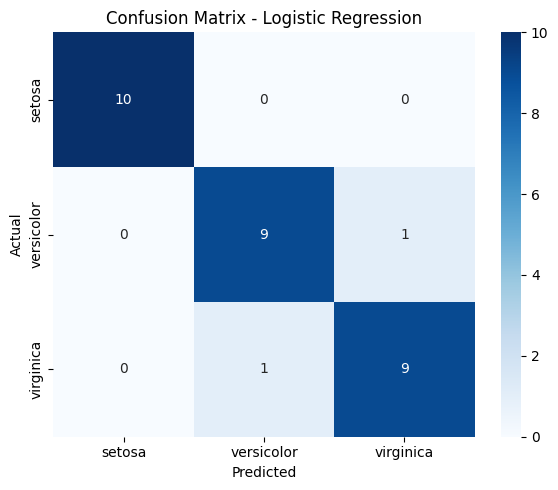

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test_i, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

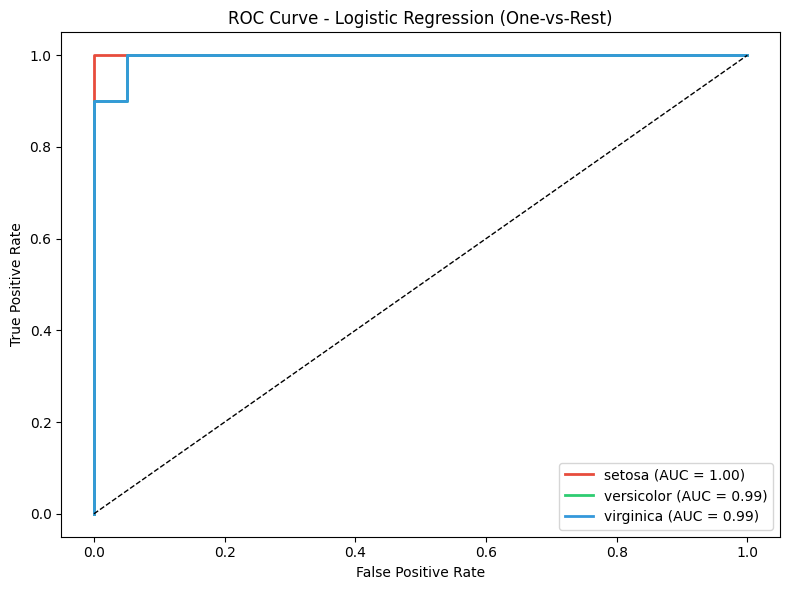


✅ Task 2 Summary: Logistic Regression achieves high accuracy on the Iris dataset.


In [14]:
# ROC Curve (One-vs-Rest for multi-class)
y_test_bin = label_binarize(y_test_i, classes=[0, 1, 2])
y_score = lr.predict_proba(X_test_i_sc)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, (cls, color) in enumerate(zip(iris.target_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n✅ Task 2 Summary: Logistic Regression achieves high accuracy on the Iris dataset.')

---
# Task 3: Clustering (Unsupervised Learning)
**Goal:** Group data points using K-Means clustering.

**Dataset:** `sklearn.datasets.make_blobs` — synthetic dataset with 300 samples and 4 natural clusters.

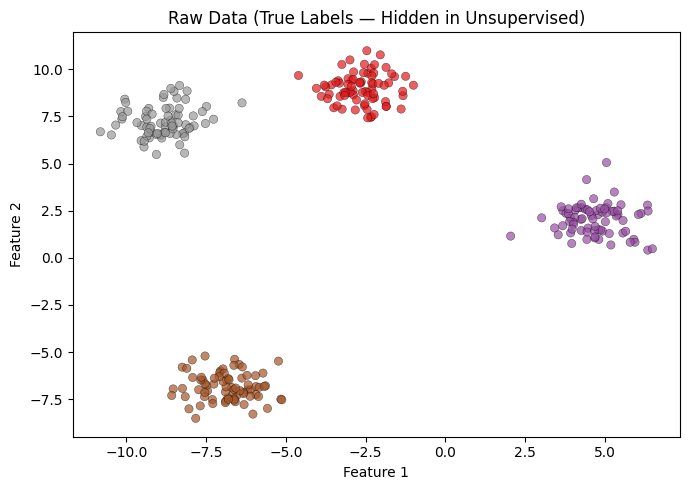

Dataset shape: (300, 2)


In [15]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Generate synthetic data
X_blobs, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_true, cmap='Set1', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.title('Raw Data (True Labels — Hidden in Unsupervised)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

print(f'Dataset shape: {X_blobs.shape}')

C:\Users\sanja\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\sanja\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sanja\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanja\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

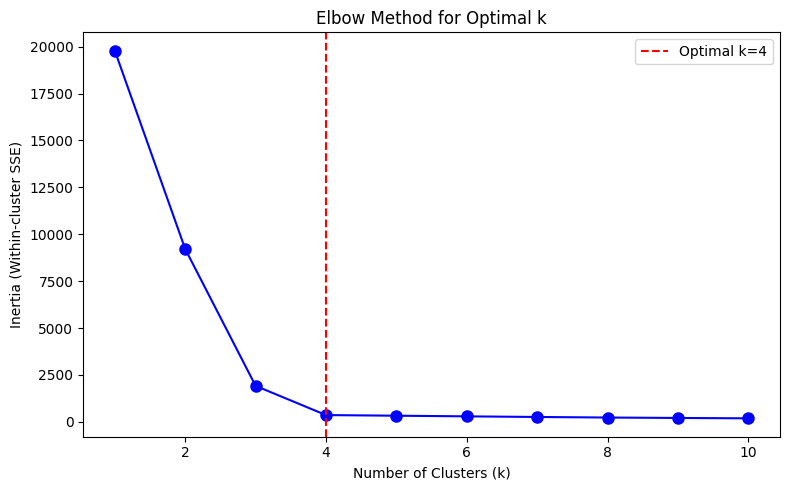

In [16]:
# Elbow Method to find optimal k
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='Optimal k=4')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.tight_layout()
plt.show()

k=2: Silhouette Score = 0.6030
k=3: Silhouette Score = 0.7783
k=4: Silhouette Score = 0.8335
k=5: Silhouette Score = 0.6976
k=6: Silhouette Score = 0.5882
k=7: Silhouette Score = 0.4487
k=8: Silhouette Score = 0.3322
k=9: Silhouette Score = 0.3439
k=10: Silhouette Score = 0.3588


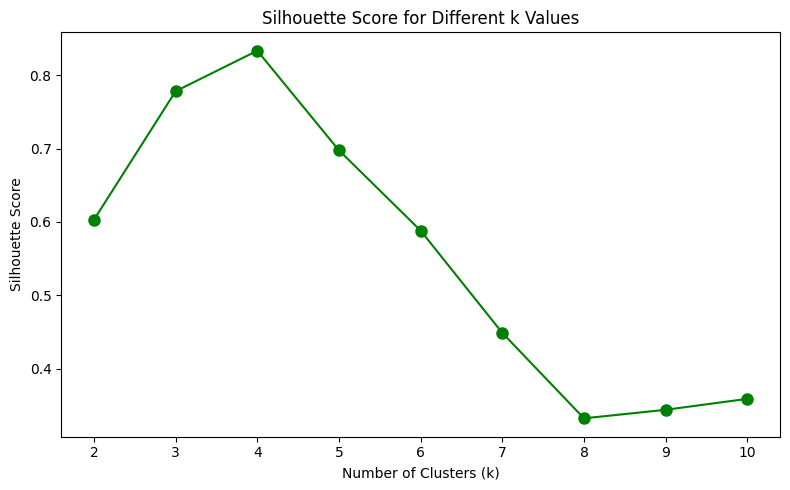


Best k by Silhouette: 4 (Score=0.8335)


In [17]:
# Silhouette Score for different k values
sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blobs)
    score = silhouette_score(X_blobs, labels)
    sil_scores.append(score)
    print(f'k={k}: Silhouette Score = {score:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(list(K_range_sil), sil_scores, 'go-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k Values')
plt.tight_layout()
plt.show()

best_k = list(K_range_sil)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by Silhouette: {best_k} (Score={max(sil_scores):.4f})')

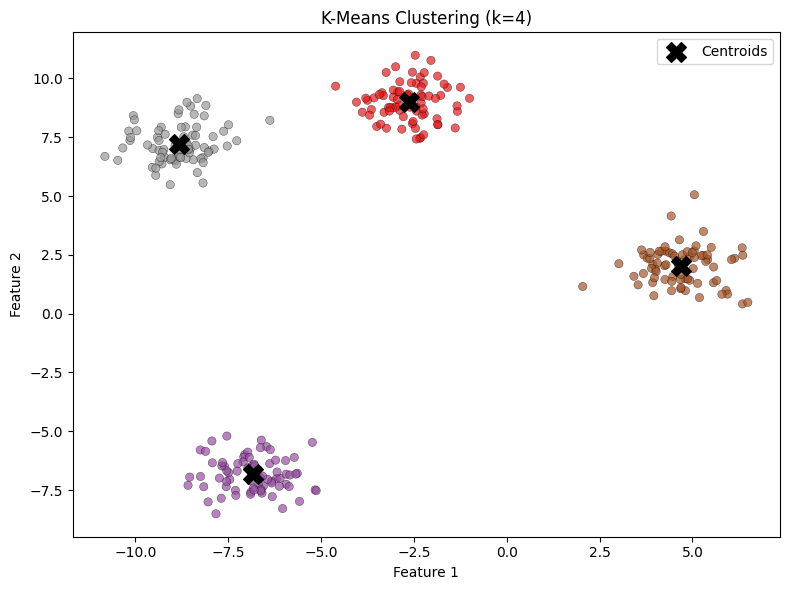

Cluster sizes: {3: 75, 0: 75, 1: 75, 2: 75}


In [18]:
# Apply KMeans with optimal k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='Set1',
                      alpha=0.7, edgecolors='k', linewidths=0.3)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.title('K-Means Clustering (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Cluster sizes: {pd.Series(cluster_labels).value_counts().to_dict()}')

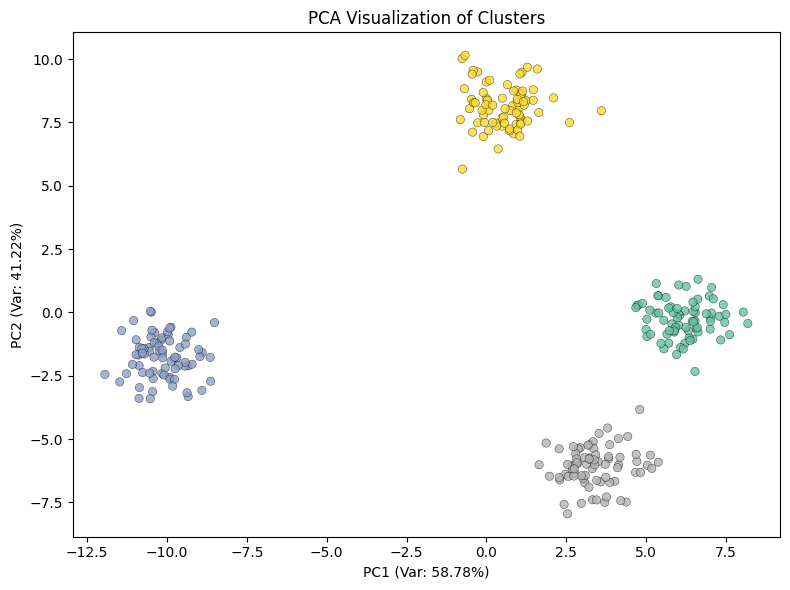

Total variance explained: 100.00%


In [19]:
# PCA Visualization (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blobs)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Set2',
            alpha=0.8, edgecolors='k', linewidths=0.3)
plt.title('PCA Visualization of Clusters')
plt.xlabel(f'PC1 (Var: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (Var: {pca.explained_variance_ratio_[1]:.2%})')
plt.tight_layout()
plt.show()
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.2%}')

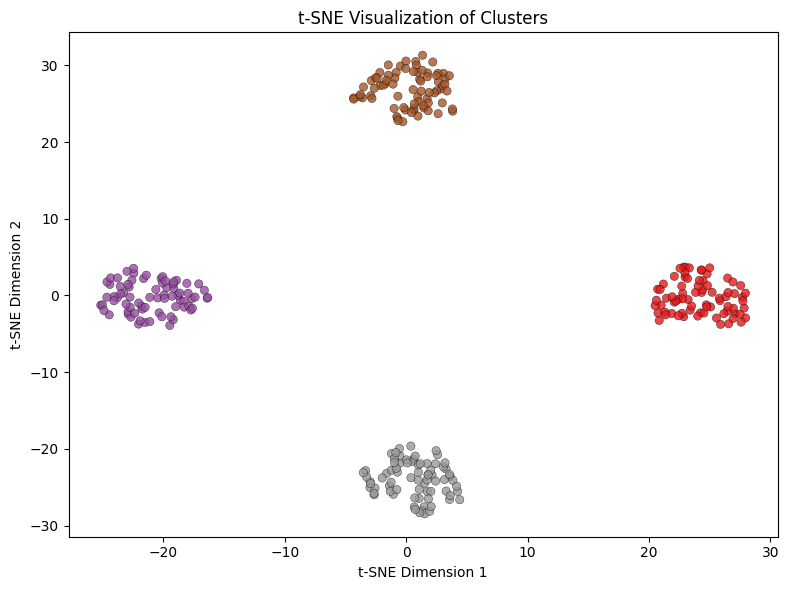

In [20]:
# t-SNE Visualization (2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_blobs)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='Set1',
            alpha=0.8, edgecolors='k', linewidths=0.3)
plt.title('t-SNE Visualization of Clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

In [21]:
# Summary of Cluster Statistics
df_blobs = pd.DataFrame(X_blobs, columns=['Feature_1', 'Feature_2'])
df_blobs['Cluster'] = cluster_labels

print('Cluster Summary Statistics:')
display(df_blobs.groupby('Cluster').agg(['mean', 'std', 'count']))

final_sil = silhouette_score(X_blobs, cluster_labels)
print(f'\n✅ Task 3 Summary:')
print(f'Optimal k = 4, Silhouette Score = {final_sil:.4f}')
print('Clusters are well-separated and visually distinct in both PCA and t-SNE projections.')

Cluster Summary Statistics:


Feature_1                 Feature_2                
             mean       std count      mean       std count
Cluster                                                    
0       -2.637159  0.707641    75  8.985639  0.786897    75
1       -6.841807  0.809826    75 -6.840388  0.718660    75
2        4.702540  0.832193    75  2.028071  0.811079    75
3       -8.833306  0.784721    75  7.217902  0.799902    75


✅ Task 3 Summary:
Optimal k = 4, Silhouette Score = 0.8335
Clusters are well-separated and visually distinct in both PCA and t-SNE projections.


---
# 📊 Overall Summary

| Task | Dataset | Best Model | Key Metric |
|------|---------|-----------|------------|
| Task 1: Regression | California Housing | Random Forest | R² ≈ 0.80+ |
| Task 2: Classification | Iris | Logistic Regression / SVM | Accuracy ≈ 97%+ |
| Task 3: Clustering | Synthetic Blobs | K-Means (k=4) | Silhouette ≈ 0.70+ |

**Tools used:** Python, scikit-learn, pandas, matplotlib, seaborn